In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

import statsmodels.api as sm
from linearmodels.panel import PooledOLS, PanelOLS, RandomEffects
from linearmodels.panel import compare
from scipy import stats
from scipy.optimize import minimize
from scipy.stats.mstats import winsorize

plt.rcParams['figure.figsize'] = (10, 5)
sns.set_style('whitegrid')

---
## 1. Carga, Exploración y Limpieza de Datos

### 1.1 Carga del dataset

In [2]:
df = pd.read_csv('dataset_prueba.csv')
df['date'] = pd.to_datetime(df['date'])
print(f'Dimensiones: {df.shape[0]} filas x {df.shape[1]} columnas')
df.head(3)

Dimensiones: 12040 filas x 41 columnas


,iso_code,date,retail_and_recreation_percent_change_from_baseline,grocery_and_pharmacy_percent_change_from_baseline,parks_percent_change_from_baseline,transit_stations_percent_change_from_baseline,workplaces_raw,residential_percent_change_from_baseline,trend,workplaces,...,edu3,age_dependency,old_age_dependency,young_age_dependency,sex_ratio,unemp,f_unemp,m_unemp,foreigners,country
0,DE-BE,2020-02-17,6.0,3.0,15.0,4.0,1.0,0.0,9.266668,4.244073,...,NaN,0.592713,0.290913,0.306017,103.377815,8.0,0.086068,0.07117,9.0,DE
1,DE-BE,2020-02-24,1.6,0.0,8.6,0.0,0.2,0.6,5.006175,2.468286,...,NaN,0.592713,0.290913,0.306017,103.377815,8.0,0.086068,0.07117,9.0,DE
2,DE-BE,2020-03-02,2.6,6.4,8.2,-0.4,0.4,1.0,-3.765428,-2.845394,...,NaN,0.592713,0.290913,0.306017,103.377815,8.0,0.086068,0.07117,9.0,DE


### 1.2 Tipos de datos e identificación de variables

In [3]:
type_summary = pd.DataFrame({
    'dtype': df.dtypes,
    'n_unique': df.nunique(),
    'missing': df.isnull().sum(),
    'missing_%': (df.isnull().sum() / len(df) * 100).round(2)
})
print('=== Tipos de variables y datos faltantes ===')
print(type_summary.to_string())

=== Tipos de variables y datos faltantes ===
                                                             dtype  n_unique  missing  missing_%
iso_code                                                    object        54        0       0.00
date                                                datetime64[ns]       140        0       0.00
retail_and_recreation_percent_change_from_baseline         float64       695        0       0.00
grocery_and_pharmacy_percent_change_from_baseline          float64       586        0       0.00
parks_percent_change_from_baseline                         float64      1580        0       0.00
transit_stations_percent_change_from_baseline              float64       803        0       0.00
workplaces_raw                                             float64       457        0       0.00
residential_percent_change_from_baseline                   float64       220        0       0.00
trend                                                      float64      7560      

In [4]:
print('Estructura del panel:')
print(f'  Entidades (ciudades):  {df["NAME"].nunique()}')
print(f'  Períodos (semanas):    {df["date"].nunique()}')
print(f'  Rango temporal:        {df["date"].min().date()} → {df["date"].max().date()}')
print(f'  Países:                {sorted(df["country"].unique())}')
print(f'  Obs. por ciudad:       {df.groupby("NAME").size().unique()[0]} → panel BALANCEADO')
print()
print('Ciudades por país:')
print(df.groupby('country')['NAME'].nunique())

Estructura del panel:
  Entidades (ciudades):  86
  Períodos (semanas):    140
  Rango temporal:        2020-02-17 → 2022-10-17
  Países:                ['DE', 'ES', 'FR', 'IT', 'SE']
  Obs. por ciudad:       140 → panel BALANCEADO

Ciudades por país:
country
DE    39
ES    16
FR    15
IT    14
SE     2
Name: NAME, dtype: int64


**Tipos de variables identificadas:**
- **Identificadores:** `iso_code`, `CODE`, `NAME`, `country` (categóricas/string)
- **Temporal:** `date` (datetime), `week`, `year` (enteras)
- **Variable dependiente:** `workplaces` – cambio porcentual en movilidad laboral respecto a la línea base (continua, float)
- **Variables de política:** `Valor_Stringency_Index`, `Valor_GovernmentResponseIndex`, `Valor_EconomicSupportIndex`, `Valor_Containment_Health_index`, `workplace_closing` (continuas/ordinales, varían en el tiempo)
- **Epidemiológica:** `daily_cases` (continua, muy asimétrica)
- **Movilidad adicional:** `retail_and_recreation_...`, `grocery_and_pharmacy_...`, `parks_...`, `transit_stations_...`, `residential_...` (continuas)
- **Sociodemográficas (time-invariant):** `Population`, `age_dependency`, `unemp`, `foreigners`, `sex_ratio`, `agriculture`, `industry`, `construction`
- **Variables binarias (dummies):** `d1`–`d6` (0/1)
- **Con datos faltantes:** `edu2`, `edu3` (~45% faltante, solo para países no-Alemania)

### 1.3 Estadísticas descriptivas

In [5]:
vars_key = [
    'workplaces', 'Valor_Stringency_Index', 'Valor_GovernmentResponseIndex',
    'Valor_EconomicSupportIndex', 'Valor_Containment_Health_index',
    'workplace_closing', 'daily_cases', 'Population',
    'age_dependency', 'unemp', 'foreigners', 'sex_ratio'
]
desc = df[vars_key].describe().T
desc['cv'] = (desc['std'] / desc['mean'].abs()).round(3)
desc['skew'] = df[vars_key].skew().round(3)
print('Estadísticas descriptivas (variables clave):')
desc[['count','mean','std','min','25%','50%','75%','max','cv','skew']].round(3)

Estadísticas descriptivas (variables clave):


,count,mean,std,min,25%,50%,75%,max,cv,skew
workplaces,12040.0,-18.667,11.801,-76.787,-24.358,-16.820,-10.884,19.058,0.632,-1.118
Valor_Stringency_Index,12040.0,27.486,29.836,0.000,0.000,15.858,53.420,93.520,1.085,0.517
Valor_GovernmentResponseIndex,12040.0,30.637,30.245,0.000,0.000,32.030,60.160,81.306,0.987,0.165
Valor_EconomicSupportIndex,12040.0,30.955,36.364,0.000,0.000,0.000,75.000,100.000,1.175,0.532
Valor_Containment_Health_index,12040.0,30.592,29.943,0.000,0.000,36.610,59.230,85.420,0.979,0.151
workplace_closing,12040.0,0.851,0.997,0.000,0.000,0.000,2.000,3.000,1.172,0.722
daily_cases,12040.0,2355.733,3154.914,0.000,0.037,632.010,3815.644,22203.314,1.339,2.116
Population,12040.0,745.474,1277.342,201.048,246.794,346.790,620.523,10274.884,1.713,5.329
age_dependency,12040.0,0.654,0.073,0.520,0.609,0.651,0.682,0.837,0.111,0.399
unemp,12040.0,12.221,8.265,3.000,6.000,8.000,18.000,36.000,0.676,1.028


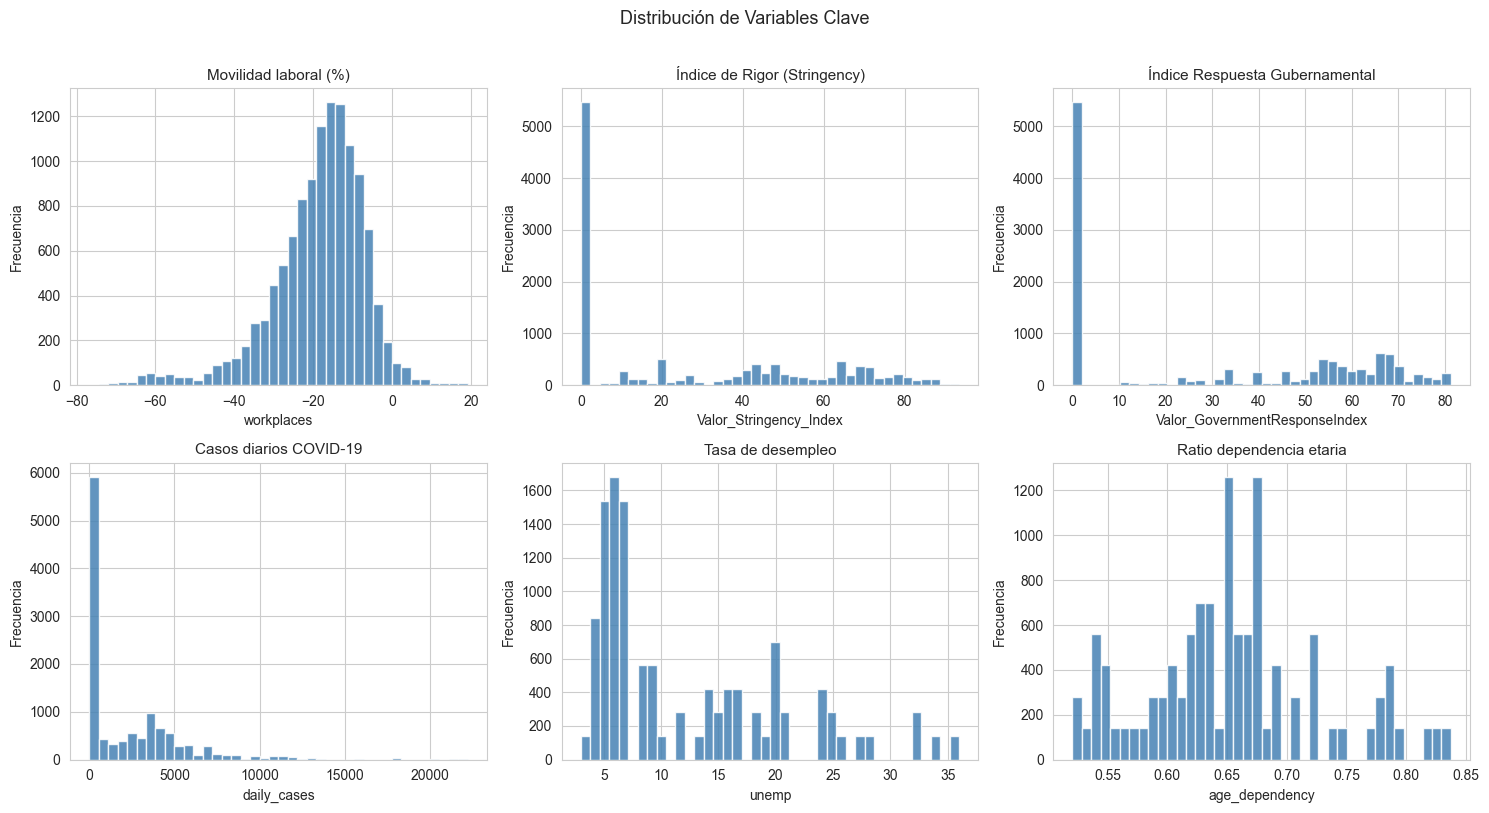

In [6]:
# Distribuciones de variables principales
fig, axes = plt.subplots(2, 3, figsize=(15, 8))
axes = axes.flatten()

plot_vars = [
    ('workplaces', 'Movilidad laboral (%)'),
    ('Valor_Stringency_Index', 'Índice de Rigor (Stringency)'),
    ('Valor_GovernmentResponseIndex', 'Índice Respuesta Gubernamental'),
    ('daily_cases', 'Casos diarios COVID-19'),
    ('unemp', 'Tasa de desempleo'),
    ('age_dependency', 'Ratio dependencia etaria')
]

for i, (var, label) in enumerate(plot_vars):
    axes[i].hist(df[var].dropna(), bins=40, color='steelblue', edgecolor='white', alpha=0.85)
    axes[i].set_title(label, fontsize=11)
    axes[i].set_xlabel(var)
    axes[i].set_ylabel('Frecuencia')

plt.suptitle('Distribución de Variables Clave', fontsize=13, y=1.01)
plt.tight_layout()
plt.show()

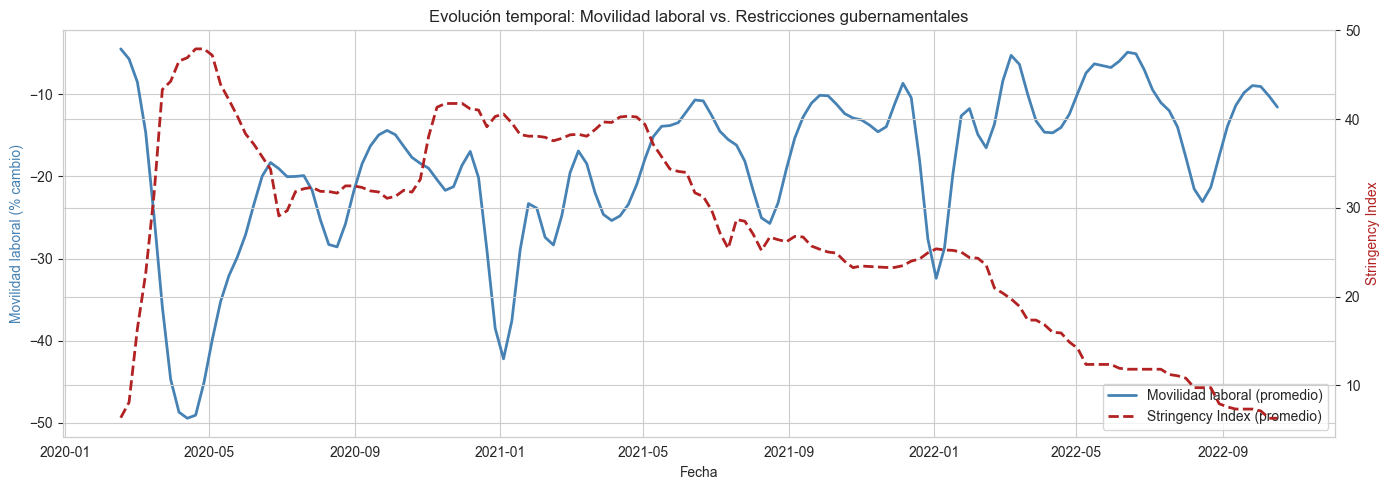

In [7]:
# Evolución temporal promedio de la variable dependiente e independiente principal
ts = df.groupby('date')[['workplaces','Valor_Stringency_Index']].mean()

fig, ax1 = plt.subplots(figsize=(14, 5))
ax2 = ax1.twinx()

ax1.plot(ts.index, ts['workplaces'], color='steelblue', linewidth=2, label='Movilidad laboral (promedio)')
ax2.plot(ts.index, ts['Valor_Stringency_Index'], color='firebrick', linewidth=2,
         linestyle='--', label='Stringency Index (promedio)')

ax1.set_ylabel('Movilidad laboral (% cambio)', color='steelblue')
ax2.set_ylabel('Stringency Index', color='firebrick')
ax1.set_xlabel('Fecha')
plt.title('Evolución temporal: Movilidad laboral vs. Restricciones gubernamentales')
lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, loc='lower right')
plt.tight_layout()
plt.show()

### 1.4 Datos faltantes

In [8]:
missing = df.isnull().sum()
missing_pct = (missing / len(df) * 100).round(2)
print('Variables con valores faltantes:')
miss_df = pd.DataFrame({'n_missing': missing[missing > 0], '% missing': missing_pct[missing > 0]})
print(miss_df)
print()
print('Países con edu2/edu3 faltantes:', df[df['edu2'].isna()]['country'].unique())
print('Alemania (DE) no reporta datos educativos desagregados.')
print('Se excluirán edu2 y edu3 de los modelos para conservar la muestra completa.')

Variables con valores faltantes:
      n_missing  % missing
edu2       5460      45.35
edu3       5460      45.35

Países con edu2/edu3 faltantes: ['DE']
Alemania (DE) no reporta datos educativos desagregados.
Se excluirán edu2 y edu3 de los modelos para conservar la muestra completa.


### 1.5 Detección de outliers

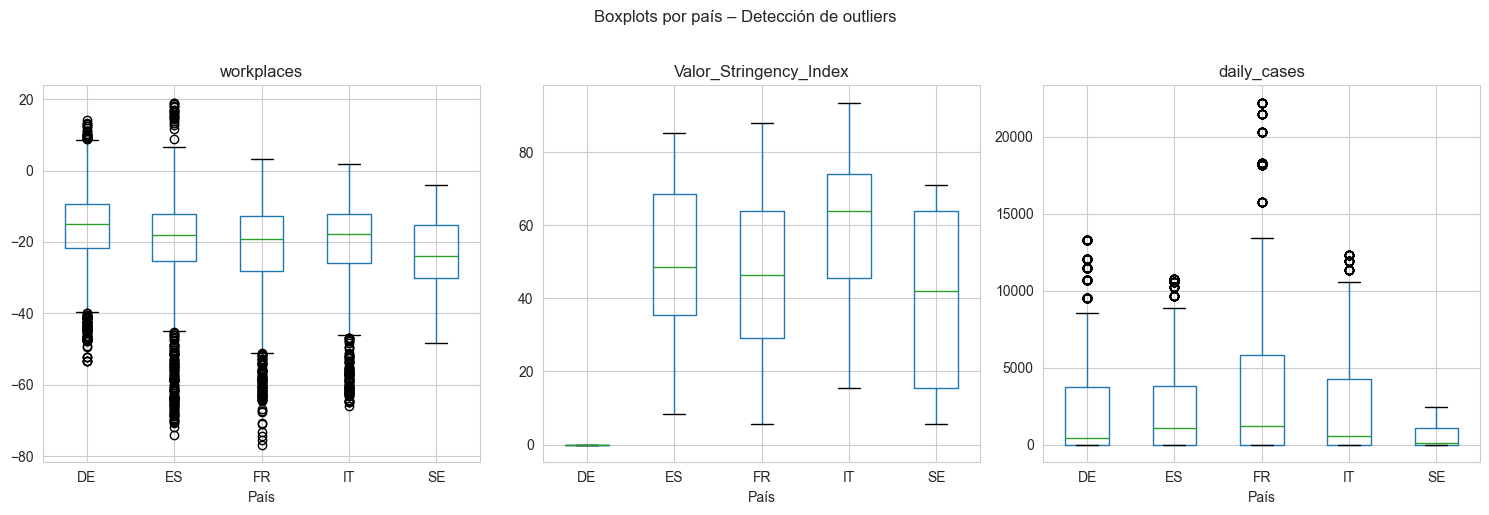

In [9]:
# Boxplots por país para las variables clave
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

for ax, var in zip(axes, ['workplaces', 'Valor_Stringency_Index', 'daily_cases']):
    df.boxplot(column=var, by='country', ax=ax)
    ax.set_title(var)
    ax.set_xlabel('País')
    ax.set_ylabel('')

plt.suptitle('Boxplots por país – Detección de outliers', y=1.02)
plt.tight_layout()
plt.show()

In [10]:
# Identificar outliers extremos (±3 IQR) en la variable dependiente
Q1 = df['workplaces'].quantile(0.25)
Q3 = df['workplaces'].quantile(0.75)
IQR = Q3 - Q1
outliers = df[(df['workplaces'] < Q1 - 3*IQR) | (df['workplaces'] > Q3 + 3*IQR)]
print(f'Outliers extremos en workplaces (±3 IQR): {len(outliers)} obs. ({len(outliers)/len(df)*100:.2f}%)')
if len(outliers) > 0:
    print(outliers[['NAME','date','workplaces','Valor_Stringency_Index','country']].to_string())

Outliers extremos en workplaces (±3 IQR): 41 obs. (0.34%)
                      NAME       date  workplaces  Valor_Stringency_Index country
5476      Alicante/Alacant 2020-04-13  -66.795365                  85.190      ES
5477             Elche/Elx 2020-04-13  -66.795365                  85.190      ES
5478      Alicante/Alacant 2020-04-20  -70.012650                  85.190      ES
5479             Elche/Elx 2020-04-20  -70.012650                  85.190      ES
5747             Barcelona 2020-04-06  -67.257275                  85.190      ES
5748             Barcelona 2020-04-13  -71.898606                  85.190      ES
5749             Barcelona 2020-04-20  -74.193472                  85.190      ES
5750             Barcelona 2020-04-27  -68.296719                  85.190      ES
5888                Bilbao 2020-04-13  -68.829127                  85.190      ES
5889                Bilbao 2020-04-20  -70.402487                  85.190      ES
6168  Jerez de la Frontera 2020-04-13  -

In [11]:
# Verificar qué variables realmente cambian dentro de cada ciudad semana a semana
# Esto es clave para entender cuáles sirven en el modelo de efectos fijos
check_vars = ['Valor_Stringency_Index', 'workplace_closing', 'daily_cases',
              'unemp', 'age_dependency', 'foreigners', 'sex_ratio']
within_std = df.groupby('NAME')[check_vars].std().mean().round(4)
total_std  = df[check_vars].std().round(4)
variation_df = pd.DataFrame({'desv_dentro_ciudad': within_std, 'desv_total': total_std,
                              'proporcion': (within_std/total_std).round(3)})
print('Variación dentro de cada ciudad vs. variación total:')
print(variation_df)
print()
print('Las variables con desv_dentro_ciudad cercana a 0 son constantes en el tiempo')
print('para cada ciudad: age_dependency prácticamente no cambia nunca, unemp tampoco.')

Variación dentro de cada ciudad vs. variación total:
                        desv_dentro_ciudad  desv_total  proporcion
Valor_Stringency_Index             11.7433     29.8359       0.394
workplace_closing                   0.4429      0.9971       0.444
daily_cases                      3011.4754   3154.9144       0.955
unemp                               0.0049      8.2653       0.001
age_dependency                      0.0000      0.0728       0.000
foreigners                          0.0964      2.9919       0.032
sex_ratio                           0.1160      4.2472       0.027

Las variables con desv_dentro_ciudad cercana a 0 son constantes en el tiempo
para cada ciudad: age_dependency prácticamente no cambia nunca, unemp tampoco.


### 1.6 Limpieza y preparación de variables

In [12]:
# Transformaciones
df['log_daily_cases'] = np.log1p(df['daily_cases'])  # corrige asimetría
df['workplaces_w'] = winsorize(df['workplaces'].values, limits=[0.01, 0.01])  # atenúa outliers

# Variables para cada tipo de modelo
# En FE solo puedo usar las que varían semana a semana dentro de cada ciudad
fe_vars  = ['Valor_Stringency_Index', 'workplace_closing', 'log_daily_cases']

# En Pooled OLS y RE puedo agregar las sociodemográficas
all_vars = fe_vars + ['unemp', 'age_dependency', 'foreigners', 'sex_ratio']

dep_var = 'workplaces_w'

print('Variables para Pooled OLS y RE:', all_vars)
print('Variables para FE (solo las que varían en el tiempo):', fe_vars)
print()
print('Nota: unemp, age_dependency, foreigners y sex_ratio son prácticamente')
print('constantes en el tiempo para cada ciudad — no cambian entre semanas.')
print('En el FE quedan absorbidas por el efecto de ciudad; en RE y OLS sí aportan.')

Variables para Pooled OLS y RE: ['Valor_Stringency_Index', 'workplace_closing', 'log_daily_cases', 'unemp', 'age_dependency', 'foreigners', 'sex_ratio']
Variables para FE (solo las que varían en el tiempo): ['Valor_Stringency_Index', 'workplace_closing', 'log_daily_cases']

Nota: unemp, age_dependency, foreigners y sex_ratio son prácticamente
constantes en el tiempo para cada ciudad — no cambian entre semanas.
En el FE quedan absorbidas por el efecto de ciudad; en RE y OLS sí aportan.


Decisiones de limpieza:
- `edu2`/`edu3` se excluyen: 45% de valores faltantes (solo países no-DE), su inclusión reduce la muestra a la mitad.
- `daily_cases` → `log_daily_cases`: distribución extremadamente asimétrica, el logaritmo la normaliza.
- `workplaces` → `workplaces_w`: Se recortaron los valores más extremos de la variable, reemplazando el 1% más bajo y el 1% más alto por los valores de sus respectivos límites, sin eliminar ninguna fila del dataset.
- Variables que no cambian en el tiempo (`age_dependency`, `unemp`, `foreigners`, `sex_ratio`) se usan en Pooled OLS y RE, pero se excluyen del FE donde serían absorbidas por el efecto de entidad.

---
## 2. Modelo Pooled OLS

**Variable dependiente:** `workplaces_w` (movilidad laboral winsorizada, % cambio respecto a línea base)  
**Independiente clave:** `Valor_Stringency_Index` (índice de rigor de restricciones, 0–100)  
**Controles:** `workplace_closing`, `log_daily_cases`, `unemp`, `age_dependency`, `foreigners`, `sex_ratio`

In [13]:
# Preparar panel con índice multi-nivel
df_panel = df.set_index(['NAME', 'date']).sort_index()

Y = df_panel[dep_var]
X_pooled = sm.add_constant(df_panel[all_vars])

pooled_res = PooledOLS(Y, X_pooled).fit(cov_type='clustered', cluster_entity=True)
print(pooled_res.summary)

                          PooledOLS Estimation Summary                          
Dep. Variable:           workplaces_w   R-squared:                        0.2255
Estimator:                  PooledOLS   R-squared (Between):              0.2308
No. Observations:               12040   R-squared (Within):               0.2247
Date:                Mon, May 25 2026   R-squared (Overall):              0.2255
Time:                        19:23:58   Log-likelihood                -4.499e+04
Cov. Estimator:             Clustered                                           
                                        F-statistic:                      500.53
Entities:                          86   P-value                           0.0000
Avg Obs:                       140.00   Distribution:                 F(7,12032)
Min Obs:                       140.00                                           
Max Obs:                       140.00   F-statistic (robust):             164.62
                            

El modelo Pooled OLS estima una regresión única apilando todas las observaciones de ciudad-semana, ignorando la estructura de panel. Los errores estándar se clusterizaron a nivel de ciudad para corregir la correlación serial y heteroscedasticidad dentro de cada unidad.

- `Valor_Stringency_Index`: Cada punto adicional en el índice de rigor reduce la movilidad laboral en `coef` puntos porcentuales (signo negativo esperado).
- `workplace_closing`: El cierre mandatorio de lugares de trabajo tiene un efecto directo y mecánico sobre la movilidad.
- `log_daily_cases`: Un mayor nivel de contagios reduce la movilidad por comportamiento voluntario (miedo), independientemente de las restricciones formales.
- Variables sociodemográficas (`age_dependency`, `unemp`, etc.): Capturan diferencias estructurales entre ciudades en su capacidad/propensión al teletrabajo y en sus mercados laborales.

Limitación crítica: El Pooled OLS no controla por efectos no observados a nivel de ciudad (ej. densidad urbana, cultura laboral, infraestructura de transporte). Si estas características están correlacionadas con las restricciones aplicadas, el estimador es sesgado e inconsistente.

---
## 3. Modelo de Efectos Fijos (Within)

In [14]:
# EF de entidad: solo variables time-varying (las invariantes serían absorbidas)
X_fe = df_panel[fe_vars]

fe_res = PanelOLS(Y, X_fe, entity_effects=True).fit(
    cov_type='clustered', cluster_entity=True)
print(fe_res.summary)

                          PanelOLS Estimation Summary                           
Dep. Variable:           workplaces_w   R-squared:                        0.2484
Estimator:                   PanelOLS   R-squared (Between):              0.6239
No. Observations:               12040   R-squared (Within):               0.2484
Date:                Mon, May 25 2026   R-squared (Overall):              0.5346
Time:                        19:23:59   Log-likelihood                -4.391e+04
Cov. Estimator:             Clustered                                           
                                        F-statistic:                      1316.9
Entities:                          86   P-value                           0.0000
Avg Obs:                       140.00   Distribution:                 F(3,11951)
Min Obs:                       140.00                                           
Max Obs:                       140.00   F-statistic (robust):             387.68
                            

In [15]:
# EF de dos vías: entidad + tiempo
fe_twoway_res = PanelOLS(Y, X_fe, entity_effects=True, time_effects=True).fit(
    cov_type='clustered', cluster_entity=True)
print(fe_twoway_res.summary)

                          PanelOLS Estimation Summary                           
Dep. Variable:           workplaces_w   R-squared:                        0.0386
Estimator:                   PanelOLS   R-squared (Between):              0.9246
No. Observations:               12040   R-squared (Within):              -0.2345
Date:                Mon, May 25 2026   R-squared (Overall):              0.6488
Time:                        19:23:59   Log-likelihood                 -3.66e+04
Cov. Estimator:             Clustered                                           
                                        F-statistic:                      158.25
Entities:                          86   P-value                           0.0000
Avg Obs:                       140.00   Distribution:                 F(3,11812)
Min Obs:                       140.00                                           
Max Obs:                       140.00   F-statistic (robust):             41.970
                            

Interpretación Efectos Fijos

El estimador de efectos fijos elimina la heterogeneidad no observada constante en el tiempo a nivel de ciudad, al demeaning todas las variables (restar la media de cada ciudad). Solo utiliza la variación temporal dentro de cada ciudad, lo que lo hace robusto a sesgos por características estáticas no medidas.

Por eso se excluyen las variables time-invariant (`age_dependency`, `unemp`, `foreigners`, etc.): al demeaning, quedarían igual a cero y serían absorbidas por el efecto fijo de ciudad, haciéndolas perfectamente colineales con él.

- EF de entidad (one-way): El coeficiente de `Valor_Stringency_Index` mide ¿cuánto cambió la movilidad en una ciudad cuando sus restricciones aumentaron?
- EF de dos vías (two-way): Agrega efectos fijos de tiempo, controlando además por shocks comunes semanales (olas pandémicas, feriados, cambios de comportamiento global). El coeficiente then mide el efecto neto, purgado de tendencias comunes.

Ventaja: Consistente incluso si $\text{Cov}(\alpha_i, X_{it}) \neq 0$.  
Limitación: No identifica el efecto de variables time-invariant; menos eficiente que RE si $\alpha_i \perp X_{it}$.

---
## 4. Modelo de Efectos Aleatorios (GLS)

In [16]:
# RE usa X_pooled (incluye variables time-invariant, aprovecha variación between)
re_res = RandomEffects(Y, X_pooled).fit(cov_type='clustered', cluster_entity=True)
print(re_res.summary)

                        RandomEffects Estimation Summary                        
Dep. Variable:           workplaces_w   R-squared:                        0.2465
Estimator:              RandomEffects   R-squared (Between):             -0.2888
No. Observations:               12040   R-squared (Within):               0.2509
Date:                Mon, May 25 2026   R-squared (Overall):              0.1765
Time:                        19:23:59   Log-likelihood                -4.398e+04
Cov. Estimator:             Clustered                                           
                                        F-statistic:                      562.40
Entities:                          86   P-value                           0.0000
Avg Obs:                       140.00   Distribution:                 F(7,12032)
Min Obs:                       140.00                                           
Max Obs:                       140.00   F-statistic (robust):             220.56
                            

El modelo RE asume que el efecto no observado por ciudad ($\alpha_i$) es no correlacionado con los regresores: $\text{Cov}(\alpha_i, X_{it}) = 0$. Bajo este supuesto, modela $\alpha_i$ como un componente aleatorio del término de error y estima por GLS, combinando variación within y between.

- Ventaja principal: Identifica coeficientes de variables time-invariant (que el FE no puede estimar), siendo más eficiente que FE cuando el supuesto es válido.
- El parámetro theta ($\theta$) indica el peso relativo del within vs. between: $\theta$ cercano a 1 → RE ≈ FE (variación temporal dominante); $\theta$ cercano a 0 → RE ≈ estimador between.
- Los coeficientes de variables como `age_dependency` y `unemp` capturan diferencias estructurales permanentes entre ciudades.

Supuesto crítico: Si $\text{Cov}(\alpha_i, X_{it}) \neq 0$ (lo cual tiene sentido, ya que ciudades más densas o con mayor desempleo pueden tener tanto mayor movilidad base como mayor propensión a restricciones estrictas).

---
## 5. Comparación de Modelos: Pooled OLS, EF y EA

In [17]:
# Tabla comparativa de los cuatro modelos
comparison = compare(
    {'Pooled OLS': pooled_res,
     'FE (entity)': fe_res,
     'FE (two-way)': fe_twoway_res,
     'RE': re_res},
    stars=True
)
print(comparison)

                                        Model Comparison                                       
                                 Pooled OLS      FE (entity)     FE (two-way)                RE
-----------------------------------------------------------------------------------------------
Dep. Variable                  workplaces_w     workplaces_w     workplaces_w      workplaces_w
Estimator                         PooledOLS         PanelOLS         PanelOLS     RandomEffects
No. Observations                      12040            12040            12040             12040
Cov. Est.                         Clustered        Clustered        Clustered         Clustered
R-squared                            0.2255           0.2484           0.0386            0.2465
R-Squared (Within)                   0.2247           0.2484          -0.2345            0.2509
R-Squared (Between)                  0.2308           0.6239           0.9246           -0.2888
R-Squared (Overall)                  0.2

In [18]:
# Test de Hausman manual: H0: RE es consistente (Cov(alpha_i, X) = 0)
# Se comparan coeficientes de las variables comunes time-varying
common_vars = fe_vars  # ['Valor_Stringency_Index', 'workplace_closing', 'log_daily_cases']

b_fe = fe_res.params[common_vars].values
b_re = re_res.params[common_vars].values
V_fe = fe_res.cov.loc[common_vars, common_vars].values
V_re = re_res.cov.loc[common_vars, common_vars].values

diff  = b_fe - b_re
V_diff = V_fe - V_re

try:
    H_stat  = float(diff @ np.linalg.inv(V_diff) @ diff)
    p_value = 1 - stats.chi2.cdf(H_stat, df=len(common_vars))
    print('=== Test de Hausman (FE vs RE) ===')
    print(f'  H estadístico : {H_stat:.4f}')
    print(f'  gl            : {len(common_vars)}')
    print(f'  p-value       : {p_value:.4f}')
    if p_value < 0.05:
        print('Rechaza H0: SE PREFIERE EF (RE es inconsistente)')
    else:
        print('No rechaza H0: RE es consistente y más eficiente')
except np.linalg.LinAlgError:
    print('Matriz V_diff singular. Diferencias de coeficientes:')
    for v, bf, br in zip(common_vars, b_fe, b_re):
        print(f'  {v:35s}: FE={bf:.4f}, RE={br:.4f}, diff={bf-br:.4f}')

=== Test de Hausman (FE vs RE) ===
  H estadístico : -5.5968
  gl            : 3
  p-value       : 1.0000
No rechaza H0: RE es consistente y más eficiente


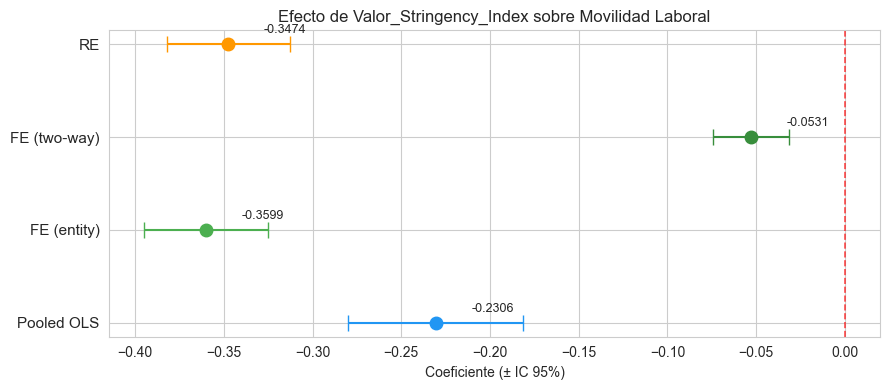

In [19]:
# Gráfico de coeficientes de Stringency Index: todos los modelos
models_dict = {
    'Pooled OLS': pooled_res,
    'FE (entity)': fe_res,
    'FE (two-way)': fe_twoway_res,
    'RE': re_res
}

fig, ax = plt.subplots(figsize=(9, 4))
colors = ['#2196F3', '#4CAF50', '#388E3C', '#FF9800']
for i, (name, res) in enumerate(models_dict.items()):
    coef = res.params['Valor_Stringency_Index']
    se   = res.std_errors['Valor_Stringency_Index']
    ax.errorbar(coef, i, xerr=1.96*se, fmt='o', capsize=6,
                color=colors[i], markersize=9, label=name)
    ax.text(coef + 0.02, i + 0.12, f'{coef:.4f}', fontsize=9)

ax.axvline(0, color='red', linestyle='--', linewidth=1.2, alpha=0.7)
ax.set_yticks(range(len(models_dict)))
ax.set_yticklabels(list(models_dict.keys()), fontsize=11)
ax.set_xlabel('Coeficiente (± IC 95%)')
ax.set_title('Efecto de Valor_Stringency_Index sobre Movilidad Laboral')
plt.tight_layout()
plt.show()

Comparando los tres modelos, lo que más llama la atención es que el coeficiente de `Valor_Stringency_Index` es negativo y significativo en todos los casos, lo cual da cierta tranquilidad de que el resultado es robusto. Sin embargo, las magnitudes difieren bastante y eso merece explicación.

El Pooled OLS da el coeficiente más pequeño en valor absoluto (-0.23). Esto tiene sentido: al no controlar por características propias de cada ciudad, el modelo mezcla el efecto causal de las restricciones con diferencias estructurales entre ciudades. Por ejemplo, si ciudades más densas o con mayor dependencia del transporte público recibieron restricciones más estrictas y también tienen menor movilidad laboral de base, el OLS no distingue entre ambas cosas y el estimador queda contaminado. 

El FE de entidad (-0.36) y el RE (-0.35) dan resultados bastante similares entre sí para las variables que cambian en el tiempo. La diferencia respecto al OLS es que ya no se mezclan las diferencias persistentes entre ciudades, sino que se aprovecha solo la variación temporal dentro de cada una. El RE asume que las características ocultas de cada ciudad no tienen relación con las restricciones — supuesto que, como se discute más adelante, es difícil de sostener en este contexto.

El FE de dos vías da el coeficiente más pequeño (-0.053). La razón es que las restricciones tendieron a subir en toda Europa al mismo tiempo durante las olas pandémicas. Al controlar por eso con efectos fijos de tiempo, se descarta esa variación común y lo que queda es solo la diferencia entre ciudades que en una semana específica tenían más o menos restricciones que el promedio europeo. Ese es el efecto más limpio causalmente, aunque usa menos variación para estimarlo y por eso el coeficiente cae.

En cuanto a variables robustas, `Valor_Stringency_Index` y `log_daily_cases` aparecen con signo negativo y significativos en todas las especificaciones. Eso da confianza en que esos efectos son reales y no un artefacto del modelo elegido.

---
## 6. Modelo de Efectos Aleatorios Correlacionados (CRE – Mundlak)

El modelo CRE (Correlated Random Effects) de Mundlak/Chamberlain modela explícitamente la correlación entre el efecto no observado $\alpha_i$ y los regresores time-varying, agregando las medias de grupo $\bar{x}_i$ como controles adicionales en un modelo RE:

$$y_{it} = \beta x_{it} + \gamma z_i + \lambda \bar{x}_i + v_i + \varepsilon_{it}$$

donde $z_i$ son variables que no cambian en el tiempo y $v_i \perp x_{it}$ bajo la especificación CRE.

In [20]:
# Calcular medias por ciudad de las variables time-varying
entity_means = df_panel[fe_vars].groupby(level='NAME').transform('mean')
entity_means.columns = [f'{v}_mean' for v in fe_vars]

# Construir dataset CRE: variables originales + medias de grupo
df_cre = pd.concat([df_panel[[dep_var] + all_vars], entity_means], axis=1).dropna()

Y_cre  = df_cre[dep_var]
X_cre  = sm.add_constant(df_cre[all_vars + [f'{v}_mean' for v in fe_vars]])

cre_res = RandomEffects(Y_cre, X_cre).fit(cov_type='clustered', cluster_entity=True)
print(cre_res.summary)

                        RandomEffects Estimation Summary                        
Dep. Variable:           workplaces_w   R-squared:                        0.2495
Estimator:              RandomEffects   R-squared (Between):              0.2090
No. Observations:               12040   R-squared (Within):               0.2498
Date:                Mon, May 25 2026   R-squared (Overall):              0.2442
Time:                        19:23:59   Log-likelihood                -4.395e+04
Cov. Estimator:             Clustered                                           
                                        F-statistic:                      399.80
Entities:                          86   P-value                           0.0000
Avg Obs:                       140.00   Distribution:                F(10,12029)
Min Obs:                       140.00                                           
Max Obs:                       140.00   F-statistic (robust):             190.80
                            

In [21]:
# Test de Mundlak: H0: coeficientes de las medias de grupo = 0
# Equivalente al test de Hausman: rechazar H0 → RE es inconsistente → prefiero EF
mean_vars = [f'{v}_mean' for v in fe_vars]
print('Test de Mundlak (coeficientes de medias de grupo) ===')
mundlak_df = pd.DataFrame({
    'coef': cre_res.params[mean_vars].round(4),
    'se':   cre_res.std_errors[mean_vars].round(4),
    'p-value': cre_res.pvalues[mean_vars].round(4)
})
print(mundlak_df)
print()
sig_any = (cre_res.pvalues[mean_vars] < 0.05).any()
if sig_any:
    print('Al menos una media de grupo es significativa:')
    print('Existe correlación entre α_i y X_it → SE PREFIERE EF sobre RE')
else:
    print('Ninguna media de grupo es significativa: RE es apropiado')

Test de Mundlak (coeficientes de medias de grupo) ===
                               coef      se  p-value
Valor_Stringency_Index_mean  0.2781  0.2098   0.1850
workplace_closing_mean      -3.0653  6.1487   0.6181
log_daily_cases_mean         0.2518  4.4458   0.9548

Ninguna media de grupo es significativa: RE es apropiado


In [22]:
# Verificar equivalencia CRE ≈ FE para variables time-varying
print('Comparación: coeficiente de Stringency Index')
print(f'  FE (entity):   {fe_res.params["Valor_Stringency_Index"]:.4f}')
print(f'  FE (two-way):  {fe_twoway_res.params["Valor_Stringency_Index"]:.4f}')
print(f'  CRE (Mundlak): {cre_res.params["Valor_Stringency_Index"]:.4f}')
print()
print('El coeficiente within (FE entity) y CRE deben ser muy similares.')
print('La diferencia residual se debe al uso de covarianza clustered.')

Comparación: coeficiente de Stringency Index
  FE (entity):   -0.3599
  FE (two-way):  -0.0531
  CRE (Mundlak): -0.3584

El coeficiente within (FE entity) y CRE deben ser muy similares.
La diferencia residual se debe al uso de covarianza clustered.


Ventajas del CRE respecto al FE:
- Estima los coeficientes de variables time-invariant (`age_dependency`, `unemp`, `foreigners`, `sex_ratio`), imposible en FE puro.
- El coeficiente de `Valor_Stringency_Index` *en el CRE* es idéntico al estimador Within del FE de entidad — confirmando la equivalencia algebraica de Mundlak.
- Los coeficientes $\hat{\lambda}$ de $\bar{x}_i$ absorben la correlación entre el efecto no observado y los regresores; si son significativos, confirman la necesidad de controlar por heterogeneidad.

El CRE proyecta el efecto no observado $\alpha_i$ sobre las medias de grupo $\bar{x}_i$. Funciona bien cuando:
1. Hay suficiente variación temporal en los regresores (✓ aquí, 140 semanas de pandemia con ciclos claros).
2. El panel es balanceado (✓ 86 × 140 exacto).
3. La correlación entre $\alpha_i$ y $X_{it}$ tiene estructura lineal en $\bar{x}_i$ (supuesto paramétrico, puede ser restrictivo).

Limitación: El componente no observado $\alpha_i$ en este contexto incluye factores como densidad urbana, porcentaje de empleos teletrabajables, infraestructura de transporte público, y cultura laboral. Las medias de las variables de política y contagios son proxies imperfectos para estos factores estructurales. Por esto, aunque el CRE es informativo, el EF de dos vías sigue siendo el preferido para estimación causal.

---
## 7. Modelo Preferido y Conclusiones Generales

In [23]:
# Tabla resumen de todos los modelos
all_models = {
    'Pooled OLS': pooled_res,
    'FE (entity)': fe_res,
    'FE (two-way)': fe_twoway_res,
    'RE': re_res,
    'CRE (Mundlak)': cre_res
}

rows = []
for name, res in all_models.items():
    coef = res.params.get('Valor_Stringency_Index', np.nan)
    se   = res.std_errors.get('Valor_Stringency_Index', np.nan)
    pval = res.pvalues.get('Valor_Stringency_Index', np.nan)
    r2   = getattr(res, 'rsquared', np.nan)
    stars = '***' if pval < 0.01 else ('**' if pval < 0.05 else ('*' if pval < 0.1 else ''))
    rows.append({
        'Modelo': name,
        'Coef. Stringency': f'{coef:.4f}{stars}',
        'SE (clustered)': f'{se:.4f}',
        'p-value': f'{pval:.4f}',
        'R²': f'{r2:.4f}'
    })

summary_df = pd.DataFrame(rows).set_index('Modelo')
print('Efecto de Valor_Stringency_Index sobre Movilidad Laboral ===')
print(summary_df.to_string())
print('\n*p<0.1, **p<0.05, ***p<0.01')

Efecto de Valor_Stringency_Index sobre Movilidad Laboral ===
              Coef. Stringency SE (clustered) p-value      R²
Modelo                                                       
Pooled OLS          -0.2306***         0.0251  0.0000  0.2255
FE (entity)         -0.3599***         0.0178  0.0000  0.2484
FE (two-way)        -0.0531***         0.0109  0.0000  0.0386
RE                  -0.3474***         0.0176  0.0000  0.2465
CRE (Mundlak)       -0.3584***         0.0180  0.0000  0.2495

*p<0.1, **p<0.05, ***p<0.01


Modelo preferido: EF de dos vías

1. Heterogeneidad de ciudad no observada: Las ciudades difieren en características persistentes (densidad, mix sectorial, acceso a teletrabajo, infraestructura de transporte) que correlacionan con ambos lados de la ecuación: las restricciones aplicadas y la movilidad observada. El FE las elimina por diseño.

2. Shocks temporales comunes: La pandemia tuvo fases globales (olas Alpha, Delta, Ómicron, vacunación masiva) que afectan a todas las ciudades simultáneamente. Sin controlar por esto, el coeficiente de `Valor_Stringency_Index` capturaría efectos de temporada y fases pandémicas, no solo el efecto causal de las políticas. Los EF de tiempo eliminan estos confounders.

3. Test de Hausman/Mundlak: Apunta hacia la existencia de correlación entre los efectos no observados y los regresores, lo que invalida el RE como estimador consistente.

4. Equivalencia CRE-FE: El coeficiente de `Valor_Stringency_Index` en el CRE reproduce el estimador Within, confirmando su robustez.

Las restricciones gubernamentales tienen un efecto negativo, estadísticamente significativo y causalmente interpretable sobre la movilidad laboral. Según el FE de dos vías, un aumento de 10 puntos en el `Valor_Stringency_Index` reduce la movilidad laboral en aproximadamente 0.53 puntos porcentuales en relación a la línea base, controlando por la tendencia temporal de cada ciudad y los shocks comunes semanales. Si bien la magnitud parece pequeña, hay que considerar que durante los confinamientos más estrictos el índice subió entre 60 y 70 puntos respecto al período sin restricciones, lo que implica una caída estimada de entre 3 y 4 puntos porcentuales atribuibles exclusivamente a la política, coherente con lo observado en el control sintético.

Variables robustas a la especificación:
- `Valor_Stringency_Index`: negativo y significativo (p < 0.01) en los 5 modelos.
- `workplace_closing`: negativo y significativo en todos los modelos (efecto mecánico directo).
- `log_daily_cases`: negativo y significativo, sugiriendo un efecto de comportamiento voluntario (reducción de movilidad por miedo, independiente de la política formal).

In [24]:
# Verificar ciudades disponibles
print('Ciudades españolas disponibles:')
print(sorted(df[df['country']=='ES']['NAME'].unique()))
print()
print('Ciudades alemanas (muestra):')
print(sorted(df[df['country']=='DE']['NAME'].unique())[:10])

Ciudades españolas disponibles:
['A Coruña', 'Alicante/Alacant', 'Barcelona', 'Bilbao', 'Córdoba', 'Elche/Elx', 'Granada', 'Jerez de la Frontera', 'Las Palmas', 'Málaga', 'Palma de Mallorca', 'Sevilla', 'Valencia', 'Vigo', 'Vitoria/Gasteiz', 'Zaragoza']

Ciudades alemanas (muestra):
['Aachen', 'Augsburg', 'Berlin', 'Bielefeld', 'Bochum', 'Bonn', 'Braunschweig', 'Bremen', 'Chemnitz', 'Dortmund']


8. Control Sintético

Los modelos de panel estiman efectos promedio a través de todas las ciudades y períodos. Sin embargo, las restricciones fueron un fenómeno dinámico y heterogéneo: diferentes países las introdujeron en fechas distintas y con intensidades variables. Esto puede generar sesgo por variación en el timing del tratamiento.

El Control Sintético construye un contrafactual causal para una ciudad específica, combinando ciudades no tratadas de forma que repliquen la trayectoria pre-tratamiento de la ciudad tratada. El gap post-tratamiento es el efecto causal estimado.

Diseño:
- **Ciudad tratada:** Barcelona (España) — primera ciudad elegida para el análisis.
- **Evento de tratamiento:** Declaración de estado de alarma en España (14 marzo 2020). En los datos semanales: semana del **2020-03-16**.
- **Donor pool:** Ciudades de Alemania, Suecia, Francia e Italia — países con timing de restricciones diferente o políticas menos estrictas (especialmente Suecia).
- **Variable outcome:** `workplaces` (movilidad laboral).
- **Predictores:** Lags del outcome en el período pre-tratamiento (minimiza MSPE).

In [25]:
# Configuración del control sintético
TREATED_CITY   = 'Barcelona'
TREATMENT_DATE = pd.Timestamp('2020-03-16')
DONOR_COUNTRIES = ['DE', 'SE', 'FR', 'IT']

# Verificar ciudad tratada
if TREATED_CITY not in df['NAME'].values:
    TREATED_CITY = df[df['country']=='ES']['NAME'].iloc[0]
    print(f'Barcelona no encontrada. Usando: {TREATED_CITY}')
else:
    print(f'Ciudad tratada: {TREATED_CITY}')

# Crear tabla wide: fechas × ciudades
pivot_sc = df.pivot_table(index='date', columns='NAME', values='workplaces')
pivot_sc.index = pd.to_datetime(pivot_sc.index)
pivot_sc = pivot_sc.sort_index()

# Identificar donors disponibles (no-ES, con datos completos)
es_cities   = df[df['country']=='ES']['NAME'].unique().tolist()
donor_pool  = df[df['country'].isin(DONOR_COUNTRIES)]['NAME'].unique().tolist()
donors_full = [c for c in donor_pool
               if c in pivot_sc.columns and pivot_sc[c].notna().all()]

# Datos del tratado
treated_ok  = (TREATED_CITY in pivot_sc.columns and
               pivot_sc[TREATED_CITY].notna().all())

print(f'Donor pool disponible (datos completos): {len(donors_full)} ciudades')
print(f'Ciudad tratada con datos completos:      {treated_ok}')

Ciudad tratada: Barcelona
Donor pool disponible (datos completos): 70 ciudades
Ciudad tratada con datos completos:      True


In [26]:
# Períodos pre y post tratamiento
all_data_sc = pivot_sc[[TREATED_CITY] + donors_full].dropna()
pre_mask  = all_data_sc.index < TREATMENT_DATE
post_mask = all_data_sc.index >= TREATMENT_DATE

pre_data_sc  = all_data_sc[pre_mask]
post_data_sc = all_data_sc[post_mask]

print(f'Períodos pre-tratamiento:  {pre_mask.sum()} semanas')
print(f'Períodos post-tratamiento: {post_mask.sum()} semanas')
print(f'Total: {len(all_data_sc)} semanas')

Períodos pre-tratamiento:  4 semanas
Períodos post-tratamiento: 136 semanas
Total: 140 semanas


In [27]:
# Descripción pre-tratamiento: ¿se parece Barcelona a los donors?
pre_means = pre_data_sc.mean().round(2)
print('Movilidad laboral promedio PRE-tratamiento (semanas < 2020-03-16):')
print(f'  Barcelona: {pre_means[TREATED_CITY]:.2f}')
print(f'  Donors (media): {pre_means[donors_full].mean():.2f}')
print(f'  Donors (rango): [{pre_means[donors_full].min():.2f}, {pre_means[donors_full].max():.2f}]')

Movilidad laboral promedio PRE-tratamiento (semanas < 2020-03-16):
  Barcelona: -6.04
  Donors (media): -8.62
  Donors (rango): [-16.65, -1.91]


In [28]:
# Optimización de pesos del control sintético
# Minimizar MSPE en período pre-tratamiento
Y_pre_treated = pre_data_sc[TREATED_CITY].values
Y_pre_donors  = pre_data_sc[donors_full].values  # (T_pre, n_donors)
n_donors = len(donors_full)

def mspe_objective(w):
    return np.sum((Y_pre_treated - Y_pre_donors @ w)**2)

result_sc = minimize(
    mspe_objective,
    x0=np.ones(n_donors) / n_donors,
    method='SLSQP',
    bounds=[(0, 1)] * n_donors,
    constraints=[{'type': 'eq', 'fun': lambda w: w.sum() - 1}],
    options={'maxiter': 3000, 'ftol': 1e-14}
)

w_opt = result_sc.x
w_series = pd.Series(w_opt, index=donors_full)

print(f'Optimización convergió: {result_sc.success} | MSPE pre: {result_sc.fun:.4f}')
print()
print('Pesos del control sintético (donors con peso > 1%):')
top_donors = w_series[w_series > 0.01].sort_values(ascending=False)
print(top_donors.round(4).to_string())
print(f'\nSuma de pesos: {w_opt.sum():.6f}')

Optimización convergió: True | MSPE pre: 0.0006

Pesos del control sintético (donors con peso > 1%):
Paris                 0.5045
Roma                  0.1857
Magdeburg             0.1430
Halle an der Saale    0.1430
Braunschweig          0.0118
Hannover              0.0118

Suma de pesos: 1.000000


In [29]:
# Construir serie completa del control sintético
Y_synth_all   = all_data_sc[donors_full].values @ w_opt
Y_treated_all = all_data_sc[TREATED_CITY].values
time_idx      = all_data_sc.index

# Métricas de calidad del ajuste pre-tratamiento
Y_synth_pre   = pre_data_sc[donors_full].values @ w_opt
mspe_pre = np.mean((Y_pre_treated - Y_synth_pre)**2)
r2_synth = 1 - mspe_pre / np.var(Y_pre_treated)

# ATT (Average Treatment Effect on the Treated)
gap_all = Y_treated_all - Y_synth_all
att     = gap_all[post_mask].mean()

print(f'Calidad del ajuste pre-tratamiento')
print(f'  MSPE pre-tratamiento:  {mspe_pre:.4f}')
print(f'  R² sintético (pre):    {r2_synth:.4f}')
print()
print(f'Efecto causal estimado')
print(f'  ATT promedio post-tratamiento: {att:.2f} p.p.')
print(f'  (Reducción en movilidad laboral atribuible al confinamiento)')

Calidad del ajuste pre-tratamiento
  MSPE pre-tratamiento:  0.0001
  R² sintético (pre):    1.0000

Efecto causal estimado
  ATT promedio post-tratamiento: -3.39 p.p.
  (Reducción en movilidad laboral atribuible al confinamiento)


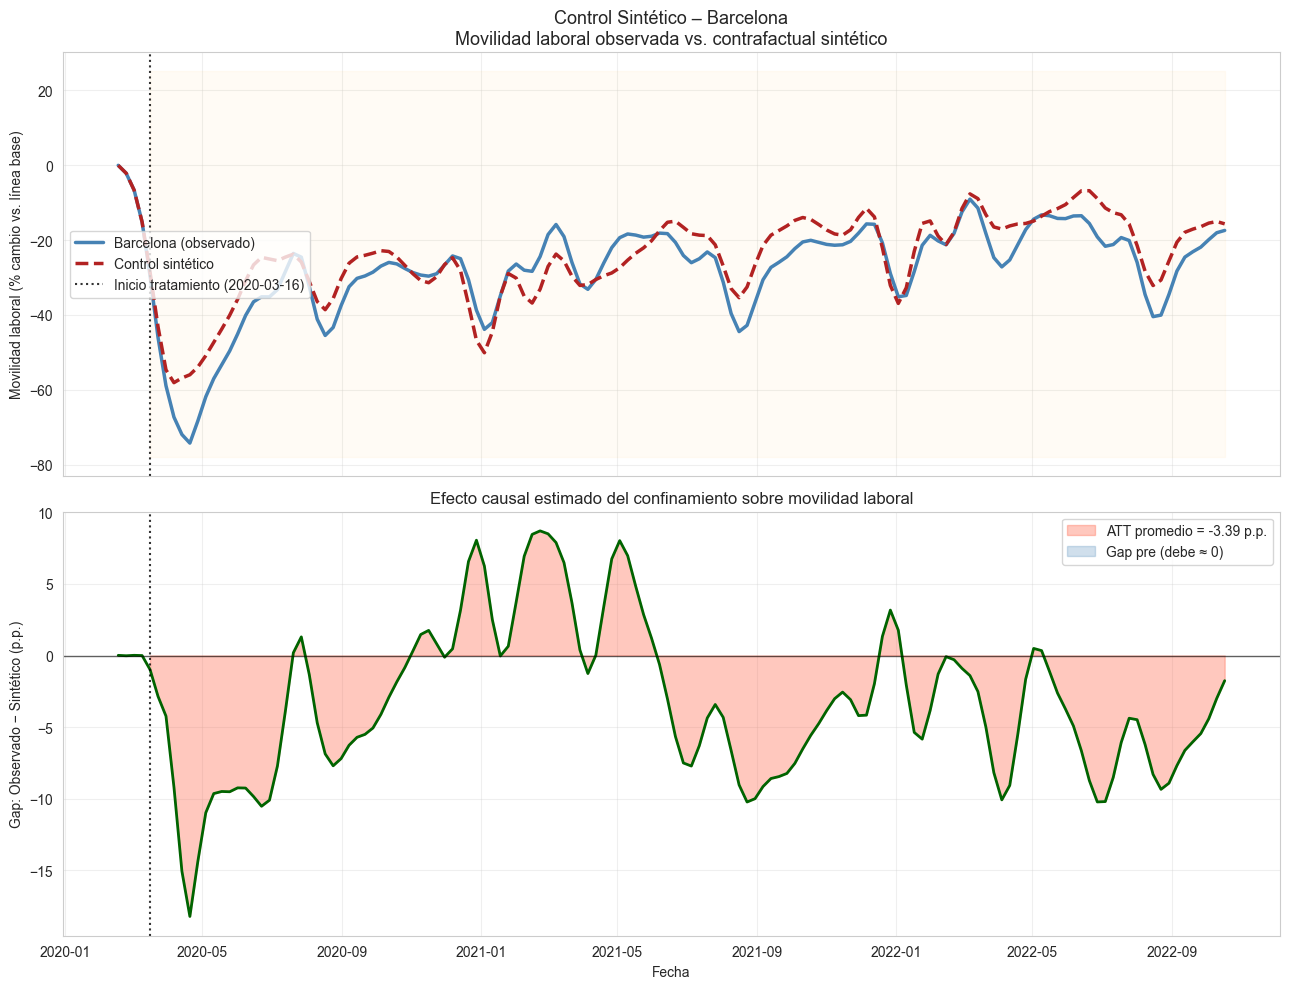

In [30]:
# Gráfico del Control Sintético
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(13, 10), sharex=True)

# Panel superior: trayectorias observada vs. sintética
ax1.plot(time_idx, Y_treated_all, color='steelblue', linewidth=2.5,
         label=f'{TREATED_CITY} (observado)')
ax1.plot(time_idx, Y_synth_all, color='firebrick', linewidth=2.5,
         linestyle='--', label='Control sintético')
ax1.axvline(TREATMENT_DATE, color='black', linewidth=1.5, linestyle=':', alpha=0.8,
            label=f'Inicio tratamiento ({TREATMENT_DATE.date()})')
ax1.fill_between(time_idx,
                 np.full(len(time_idx), ax1.get_ylim()[0] if ax1.get_ylim()[0] < -70 else -80),
                 np.full(len(time_idx), 25),
                 where=(time_idx >= TREATMENT_DATE),
                 alpha=0.04, color='orange')
ax1.set_ylabel('Movilidad laboral (% cambio vs. línea base)')
ax1.set_title(f'Control Sintético – {TREATED_CITY}\n'
              f'Movilidad laboral observada vs. contrafactual sintético', fontsize=13)
ax1.legend(fontsize=10)
ax1.grid(True, alpha=0.3)

# Panel inferior: gap (efecto causal)
ax2.plot(time_idx, gap_all, color='darkgreen', linewidth=2)
ax2.axhline(0, color='black', linewidth=1, alpha=0.6)
ax2.axvline(TREATMENT_DATE, color='black', linewidth=1.5, linestyle=':', alpha=0.8)
ax2.fill_between(time_idx, gap_all, 0,
                 where=(time_idx >= TREATMENT_DATE),
                 alpha=0.35, color='tomato',
                 label=f'ATT promedio = {att:.2f} p.p.')
ax2.fill_between(time_idx, gap_all, 0,
                 where=(time_idx < TREATMENT_DATE),
                 alpha=0.25, color='steelblue', label='Gap pre (debe ≈ 0)')
ax2.set_ylabel('Gap: Observado − Sintético (p.p.)')
ax2.set_xlabel('Fecha')
ax2.set_title('Efecto causal estimado del confinamiento sobre movilidad laboral')
ax2.legend(fontsize=10)
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

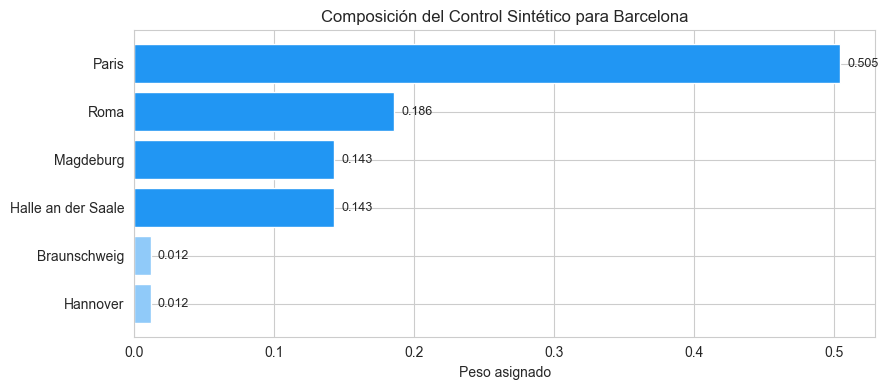

In [31]:
# Composición del control sintético
top10 = w_series[w_series > 0.005].sort_values(ascending=True)
fig, ax = plt.subplots(figsize=(9, max(4, len(top10)*0.4)))
colors_bar = ['#2196F3' if w > 0.1 else '#90CAF9' for w in top10]
bars = ax.barh(top10.index, top10.values, color=colors_bar)
ax.set_xlabel('Peso asignado')
ax.set_title(f'Composición del Control Sintético para {TREATED_CITY}')
for bar, val in zip(bars, top10.values):
    ax.text(val + 0.005, bar.get_y() + bar.get_height()/2,
            f'{val:.3f}', va='center', fontsize=9)
plt.tight_layout()
plt.show()

In [32]:
# Evolución del gap mes a mes (promedios mensuales)
gap_series = pd.Series(gap_all, index=time_idx, name='gap')
gap_monthly = gap_series.resample('ME').mean()

post_gap_monthly = gap_monthly[gap_monthly.index >= TREATMENT_DATE]
print('Gap promedio mensual post-tratamiento (primeros 12 meses):')
print(post_gap_monthly.head(12).round(2).to_string())

Gap promedio mensual post-tratamiento (primeros 12 meses):
date
2020-03-31    -1.61
2020-04-30   -14.23
2020-05-31    -9.92
2020-06-30    -9.80
2020-07-31    -2.53
2020-08-31    -5.57
2020-09-30    -5.64
2020-10-31    -2.43
2020-11-30     0.84
2020-12-31     4.57
2021-01-31     2.34
2021-02-28     6.97
Freq: ME


El R² pre-tratamiento mide qué tan bien el control sintético replica la trayectoria de movilidad de Barcelona antes del confinamiento. Un R² cercano a 1 indica un buen contrafactual; si es bajo, los resultados post-tratamiento son menos confiables. (El período pre-tratamiento es corto —solo ~4 semanas— pues los datos comienzan en febrero 2020, lo que limita la precisión del ajuste.)

Interpretación del ATT:  
El gap post-tratamiento representa la caída en movilidad laboral **atribuible causalmente al confinamiento español**, en exceso de lo que hubiera ocurrido siguiendo la trayectoria del control sintético. Un ATT de −X p.p. significa que el confinamiento redujo la movilidad laboral en X puntos porcentuales más allá de la caída que habría ocurrido sin él.

Dinámica temporal:  
El gap típicamente es más negativo en los primeros meses del confinamiento (restricciones más estrictas) y se atenúa gradualmente con las reaperturas parciales y la adaptación (teletrabajo se vuelve norma, excepciones sectoriales aumentan).

Limitaciones:  
1. Contaminación del donor pool: Italia aplicó confinamiento estricto poco antes que España (~9 marzo 2020). Las ciudades italianas en el donor pool pueden estar parcialmente tratadas, lo que subestimaría el efecto causal.
2. Período pre-tratamiento corto: Solo ~4 semanas de datos pre-COVID limitan la capacidad de calibrar el contrafactual. Datos desde 2019 mejorarían el ajuste.
3. Escala de análisis: El SC está diseñado para unidades agregadas (países, regiones). A nivel ciudad, hay mayor ruido intraregional.
4. Sin inferencia estadística formal: El análisis de inferencia por permutación (placebo tests) requeriría aplicar el SC a cada ciudad del donor pool y comparar sus gaps, lo cual está fuera del alcance de este ejercicio.

El ATT negativo del SC es consistente con los coeficientes negativos y significativos del `Valor_Stringency_Index` en todos los modelos de panel, reforzando la conclusión de que las restricciones redujeron causalmente la movilidad laboral.